In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from natsort import natsorted
import scanpy as sc

import torch
import os
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
np.set_printoptions(suppress=True)

%reload_ext autoreload
%autoreload 2

### Panel B

In [3]:
adata = sc.read_h5ad('/ssd/users/mingzegao/clonaltrans/datasets/Human_CordBlood/adata_update.h5ad')
adata

AnnData object with n_obs × n_vars = 24885 × 3462
    obs: 'Timepoint', 'gfp_late', 'GFP', 'Tissue', 'Batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'S_score', 'G2M_score', 'phase', 'label_full', 'label_red', 'clones', 'time_label_full', 'time_label_red', 'Meta clones', 'leiden', 'transferred_labels', 'prediction_score_max', 'dpt_pseudotime', 'def_lab'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'gene_removed'
    uns: 'Batch_colors', 'Timepoint_colors', 'def_lab_colors', 'diffmap_evals', 'final_lab_colors', 'hvg', 'iroot', 'label_full_colors', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'phase_colors', 'pred_corr_colors', 'rank_genes_groups', 'transferred_labels_colors', 'umap'
    obsm: 'X_diffmap', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'seurat'
    obsp: 'connectivities', 'distances'

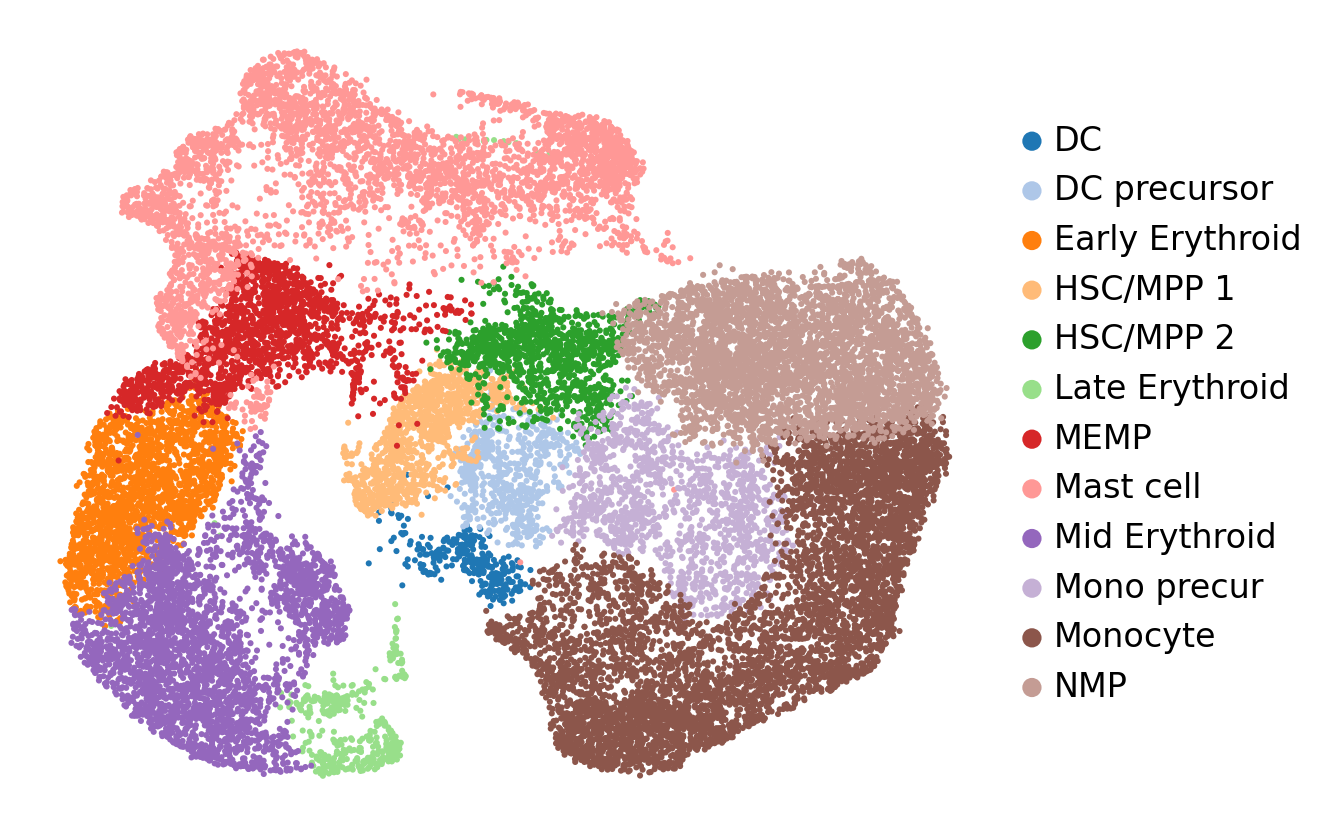

In [4]:
sc.set_figure_params(dpi_save=300, figsize=(7, 6), transparent=True)
sc.pl.scatter(
    adata, basis='umap', color='def_lab', 
    legend_loc='right margin', palette=sns.color_palette('tab20'),
    size=30, frameon=False, title='',
    legend_fontsize=15
)

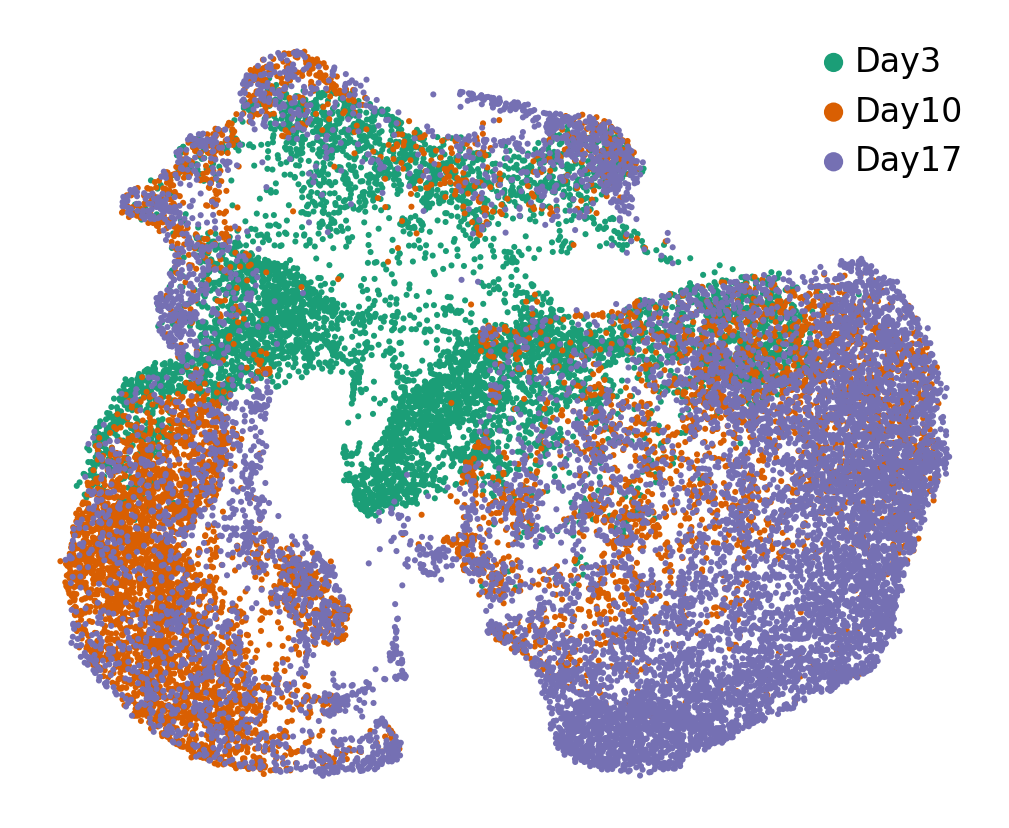

In [5]:
sc.pl.scatter(
    adata, basis='umap', color='Timepoint', 
    legend_loc='best', palette=sns.color_palette('Dark2'), 
    size=30, frameon=False, title='',
    legend_fontsize=15
)

### Panel C

In [6]:
adata = sc.read_h5ad('/ssd/users/mingzegao/clonaltrans/datasets/Human_CordBlood/adata_update.h5ad')
adata

AnnData object with n_obs × n_vars = 24885 × 3462
    obs: 'Timepoint', 'gfp_late', 'GFP', 'Tissue', 'Batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'S_score', 'G2M_score', 'phase', 'label_full', 'label_red', 'clones', 'time_label_full', 'time_label_red', 'Meta clones', 'leiden', 'transferred_labels', 'prediction_score_max', 'dpt_pseudotime', 'def_lab'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'gene_removed'
    uns: 'Batch_colors', 'Timepoint_colors', 'def_lab_colors', 'diffmap_evals', 'final_lab_colors', 'hvg', 'iroot', 'label_full_colors', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'phase_colors', 'pred_corr_colors', 'rank_genes_groups', 'transferred_labels_colors', 'umap'
    obsm: 'X_diffmap', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'seurat'
    obsp: 'connectivities', 'distances'

In [8]:
info_cb = adata.obs[['Meta clones', 'clones', 'def_lab']]
info_cb = info_cb[info_cb['Meta clones'] != "-1.0"]
info_cb['combined'] = 'Meta_' + info_cb['Meta clones'].astype(str) + '_' + info_cb['clones'].astype(str)
info_cb = info_cb.sort_values(by='combined')
info_cb

,Meta clones,clones,def_lab,combined
SITTC9CTTTCAACAGGTATGG,0,Clone_106,Mast cell,Meta_0_Clone_106
SITTB5AACAGGGGTTAGGACG,0,Clone_106,Early Erythroid,Meta_0_Clone_106
SITTC9GGGCTACCAGACAAGC,0,Clone_106,Mid Erythroid,Meta_0_Clone_106
SITTB5AGTCTCCTCAACTGGT,0,Clone_106,Early Erythroid,Meta_0_Clone_106
SITTC9ATTTACCGTGGCGCTT,0,Clone_106,Mast cell,Meta_0_Clone_106
...,...,...,...,...
SITTG7GAGACTTTCCAGGACC,9,Clone_3883,Mast cell,Meta_9_Clone_3883
SITTG7GTAGTACCACGAGGAT,9,Clone_3883,Mast cell,Meta_9_Clone_3883
SITTG7AGGGTGAGTCACAATC,9,Clone_532,Mast cell,Meta_9_Clone_532
SITTG7GATCATGCACAACATC,9,Clone_532,Mast cell,Meta_9_Clone_532


In [9]:
pivot_table = pd.crosstab(info_cb['combined'], info_cb['def_lab'])
pivot_table = pivot_table[["HSC/MPP 1", "HSC/MPP 2", "MEMP", "Mast cell", "Early Erythroid", "Mid Erythroid" , "Late Erythroid", "NMP", "Mono precur", "Monocyte", "DC precursor", "DC"]]
pivot_table = pivot_table.loc[natsorted(pivot_table.index)]
pivot_table

def_lab,HSC/MPP 1,HSC/MPP 2,MEMP,Mast cell,Early Erythroid,Mid Erythroid,Late Erythroid,NMP,Mono precur,Monocyte,DC precursor,DC
combined,,,,,,,,,,,,
Meta_0_Clone_23,0,0,0,5,12,9,0,0,0,1,0,0
Meta_0_Clone_59,0,1,0,14,0,0,0,1,0,7,0,0
Meta_0_Clone_66,0,0,0,11,8,1,3,0,0,0,0,0
Meta_0_Clone_106,0,0,0,4,6,6,2,0,0,1,0,0
Meta_0_Clone_180,0,0,0,8,10,4,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
Meta_11_Clone_3199,0,0,0,0,3,0,0,0,0,0,0,0
Meta_11_Clone_3204,0,0,1,0,2,0,0,0,0,0,0,0
Meta_11_Clone_3358,0,0,0,0,4,0,0,0,0,0,0,0


In [10]:
pivot_table[pivot_table == 0] = 0.5
pivot_table = np.log2(pivot_table)
pivot_table[pivot_table == -1] = 0
pivot_table

/tmp/ipykernel_1208053/3565897442.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  pivot_table[pivot_table == 0] = 0.5


def_lab,HSC/MPP 1,HSC/MPP 2,MEMP,Mast cell,Early Erythroid,Mid Erythroid,Late Erythroid,NMP,Mono precur,Monocyte,DC precursor,DC
combined,,,,,,,,,,,,
Meta_0_Clone_23,0.0,0.0,0.0,2.321928,3.584963,3.169925,0.000000,0.0,0.0,0.000000,0.0,0.0
Meta_0_Clone_59,0.0,0.0,0.0,3.807355,0.000000,0.000000,0.000000,0.0,0.0,2.807355,0.0,0.0
Meta_0_Clone_66,0.0,0.0,0.0,3.459432,3.000000,0.000000,1.584963,0.0,0.0,0.000000,0.0,0.0
Meta_0_Clone_106,0.0,0.0,0.0,2.000000,2.584963,2.584963,1.000000,0.0,0.0,0.000000,0.0,0.0
Meta_0_Clone_180,0.0,0.0,0.0,3.000000,3.321928,2.000000,0.000000,0.0,0.0,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
Meta_11_Clone_3199,0.0,0.0,0.0,0.000000,1.584963,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0
Meta_11_Clone_3204,0.0,0.0,0.0,0.000000,1.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0
Meta_11_Clone_3358,0.0,0.0,0.0,0.000000,2.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0


In [11]:
elements = [i.split('_')[1] for i in list(pivot_table.index)]
start_positions = {element: len(elements) - i for i, element in enumerate(reversed(elements), 1)}
start_positions

{'11': 590,
 '10': 569,
 '9': 535,
 '8': 496,
 '7': 452,
 '6': 406,
 '5': 357,
 '4': 299,
 '3': 233,
 '2': 167,
 '1': 94,
 '0': 0}

Text(0.5, 1.0, 'Cell counts in $\\it{log_2}$ scale')

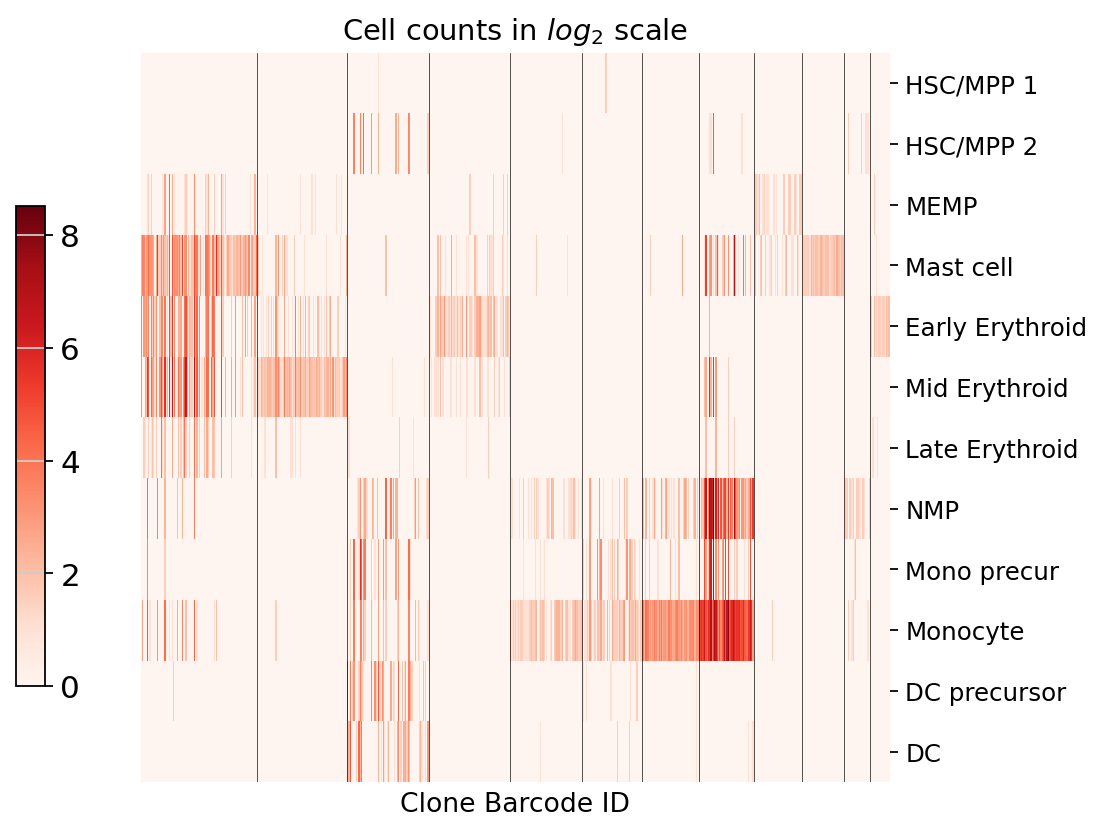

In [12]:
plt.figure(figsize=(6, 6))
plt.grid(False)

ax = sns.heatmap(
    pivot_table.T, 
    cmap='Reds', 
    annot=False,
    cbar=False
)
ax.yaxis.tick_right()
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)
ax.set_xticklabels('')

ax.set_xticks([])
ax.set_xticklabels([])

cbar_ax = ax.figure.add_axes([0.05, 0.25, 0.03, 0.5])  # x, y, width, height
cbar = ax.figure.colorbar(ax.collections[0], cax=cbar_ax)

for pos in start_positions.keys():
    if pos == '0':
        pass
    else:
        ax.axvline(start_positions[pos], color='black', linewidth=0.3)

ax.set_xlabel('Clone Barcode ID', fontsize=12)
ax.set_ylabel('')
ax.set_title('Cell counts in $\it{log_2}$ scale', fontsize=13)

### Panel D

In [13]:
adata = sc.read_h5ad('/ssd/users/mingzegao/clonaltrans/datasets/Human_CordBlood/adata_update.h5ad')
adata

AnnData object with n_obs × n_vars = 24885 × 3462
    obs: 'Timepoint', 'gfp_late', 'GFP', 'Tissue', 'Batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'S_score', 'G2M_score', 'phase', 'label_full', 'label_red', 'clones', 'time_label_full', 'time_label_red', 'Meta clones', 'leiden', 'transferred_labels', 'prediction_score_max', 'dpt_pseudotime', 'def_lab'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'gene_removed'
    uns: 'Batch_colors', 'Timepoint_colors', 'def_lab_colors', 'diffmap_evals', 'final_lab_colors', 'hvg', 'iroot', 'label_full_colors', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'phase_colors', 'pred_corr_colors', 'rank_genes_groups', 'transferred_labels_colors', 'umap'
    obsm: 'X_diffmap', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'seurat'
    obsp: 'connectivities', 'distances'

In [14]:
group_labels = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11']
adata.obs['group'] = pd.Categorical(adata.obs['Meta clones'], categories=group_labels)

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


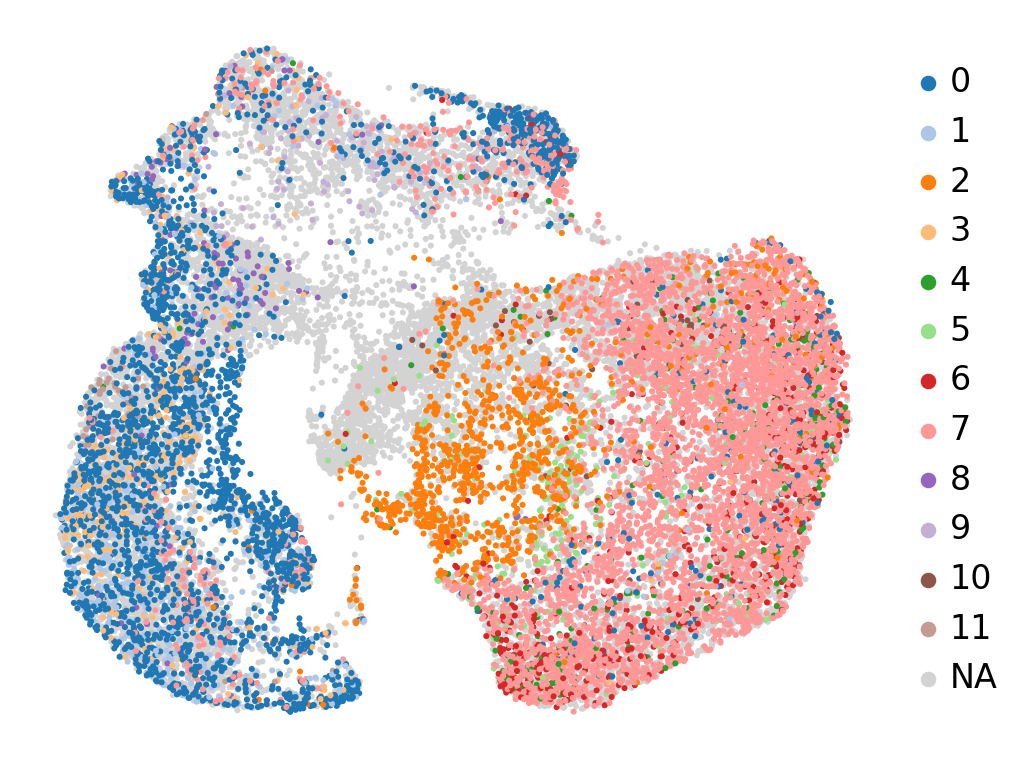

In [15]:
sc.set_figure_params(dpi_save=300, figsize=(7, 6), transparent=True)
sc.pl.umap(
    adata, color=['group'], size=30, legend_loc='right margin', 
    palette=sns.color_palette('tab20'),
    frameon=False, title='', legend_fontsize=15
)

### Panel E

In [16]:
import os 
os.chdir('/ssd/users/mingzegao/clonaltrans/clonaltrans/')

path = '../trials/v1.2.0/checkpoints/CordBloodDynamicRates/1213_100718/model_last.pt'
model = torch.load(path, map_location='cpu')
device = torch.device('cpu')

import os 
os.chdir('/ssd/users/mingzegao/clonaltrans/')

Calculating transition rates for time point 0.00:   0%|          | 0/18 [00:00<?, ?it/s]/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/torchdiffeq/_impl/misc.py:296: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")
Calculating transition rates for time point 17.00: 100%|██████████| 18/18 [00:03<00:00,  5.08it/s]


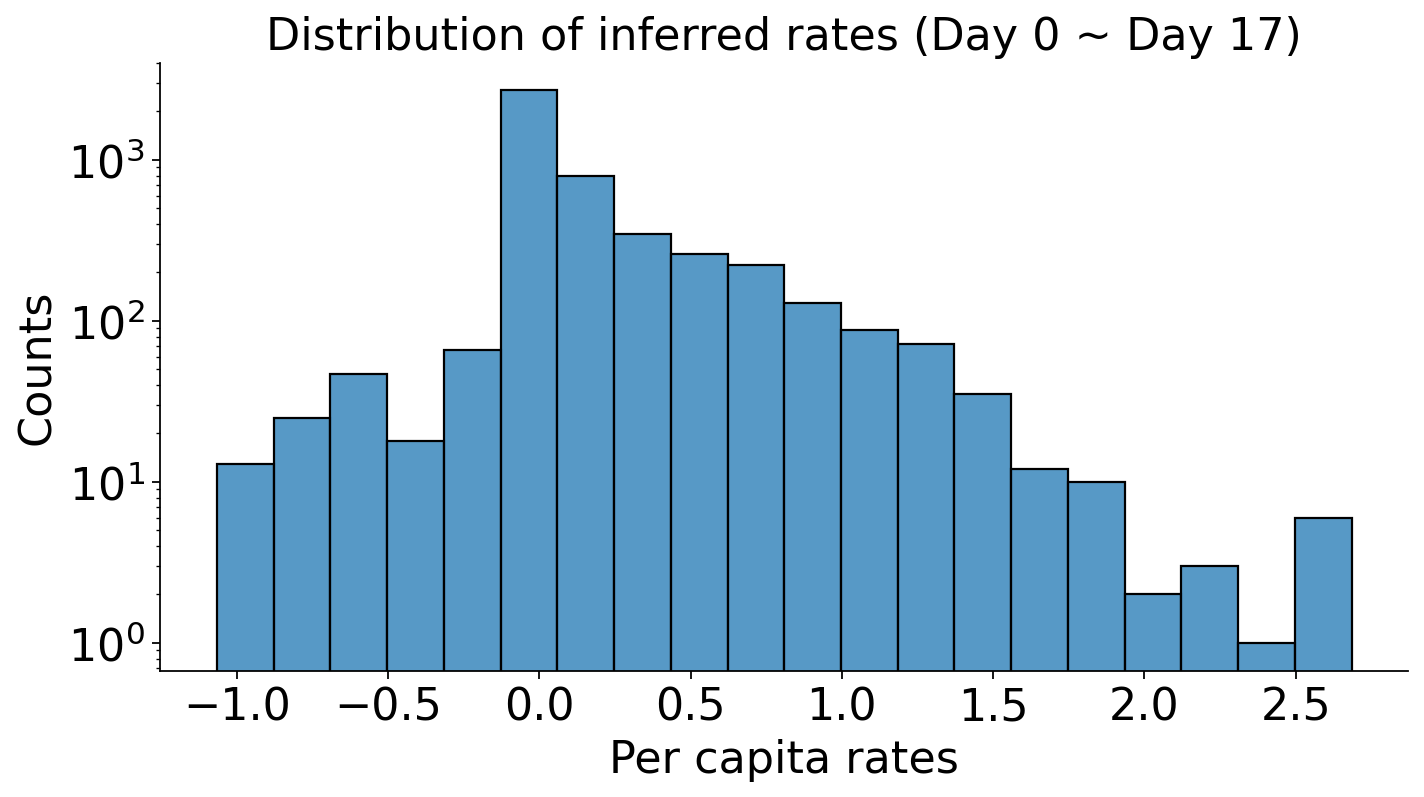

In [17]:
from clonaltrans.pl import rates_in_paga
rates_in_paga(model, save='cb_dist_rates.svg')

Calculating transition rates for time point 0.00:   0%|          | 0/18 [00:00<?, ?it/s]/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/torchdiffeq/_impl/misc.py:296: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")
Calculating transition rates for time point 17.00: 100%|██████████| 18/18 [00:03<00:00,  5.16it/s]


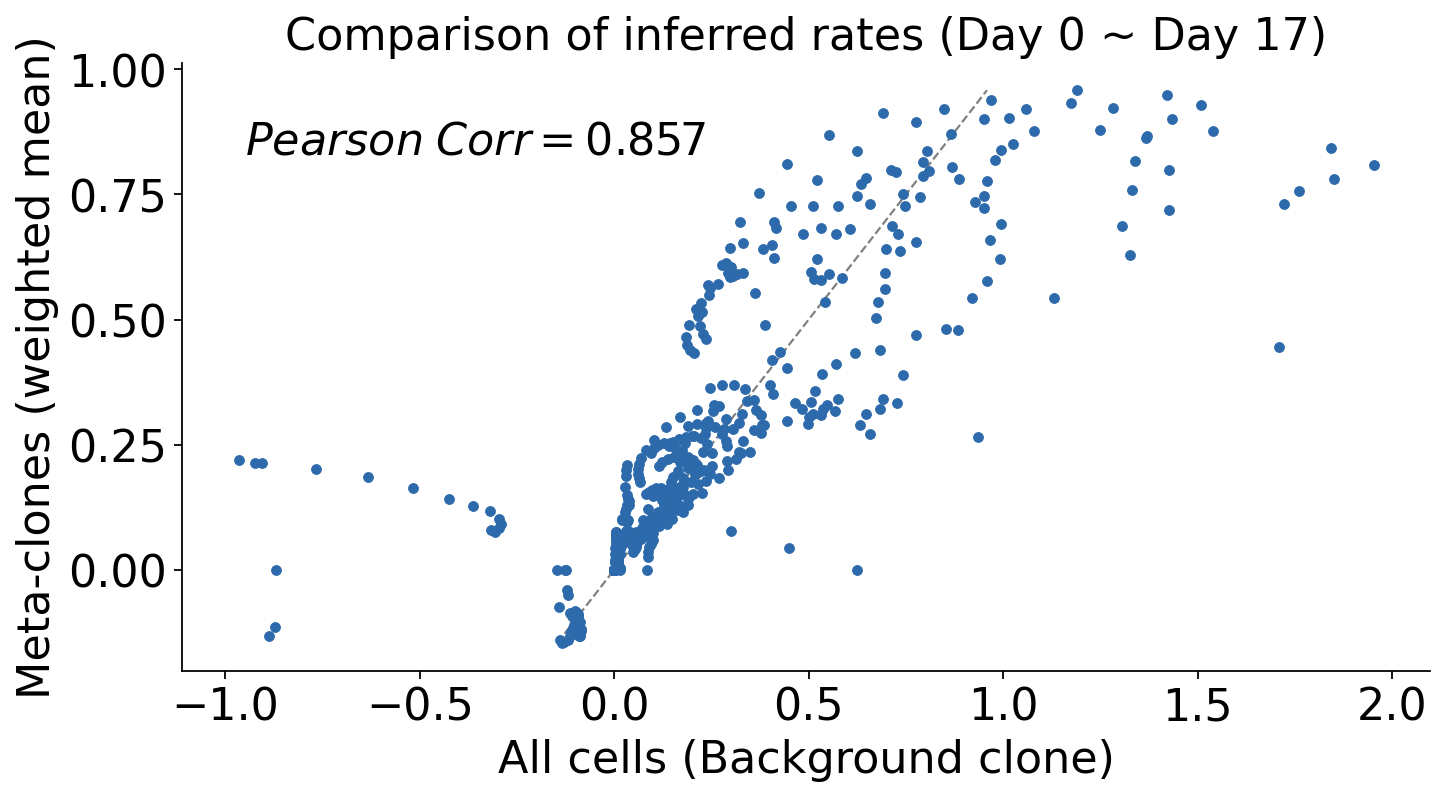

In [18]:
from clonaltrans.pl import compare_with_bg
compare_with_bg(model, save='cb_bg_rates.svg')

### Panel F

In [2]:
import os 
os.chdir('/ssd/users/mingzegao/clonaltrans/clonaltrans/')

path = '../trials/v1.2.0/checkpoints/CordBloodDynamicRates/1213_100718/model_last.pt'
model = torch.load(path, map_location='cpu')

device = torch.device('cpu')

import os 
os.chdir('/ssd/users/mingzegao/clonaltrans/')

In [3]:
model_list = []

for name in tqdm(os.listdir("./trials/v1.2.0/checkpoints/CordBloodDynamicBoots/1213_115849/models")):
    if os.path.exists(os.path.join("./trials/v1.2.0/checkpoints/CordBloodDynamicBoots/1213_115849/models", name, f'{name}.pt')):
        model_list.append(torch.load(os.path.join(f"./trials/v1.2.0/checkpoints/CordBloodDynamicBoots/1213_115849/models", name, f'{name}.pt'), map_location='cuda:1'))

  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [00:07<00:00, 71.04it/s]


Trajectory of model 0: : 0it [00:00, ?it/s]/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/torchdiffeq/_impl/misc.py:296: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")
Trajectory of model 21: : 21it [00:23,  1.28s/it]

Trajectory of model 500: : 501it [07:35,  1.10it/s]


# of used bootstrapping models: 501


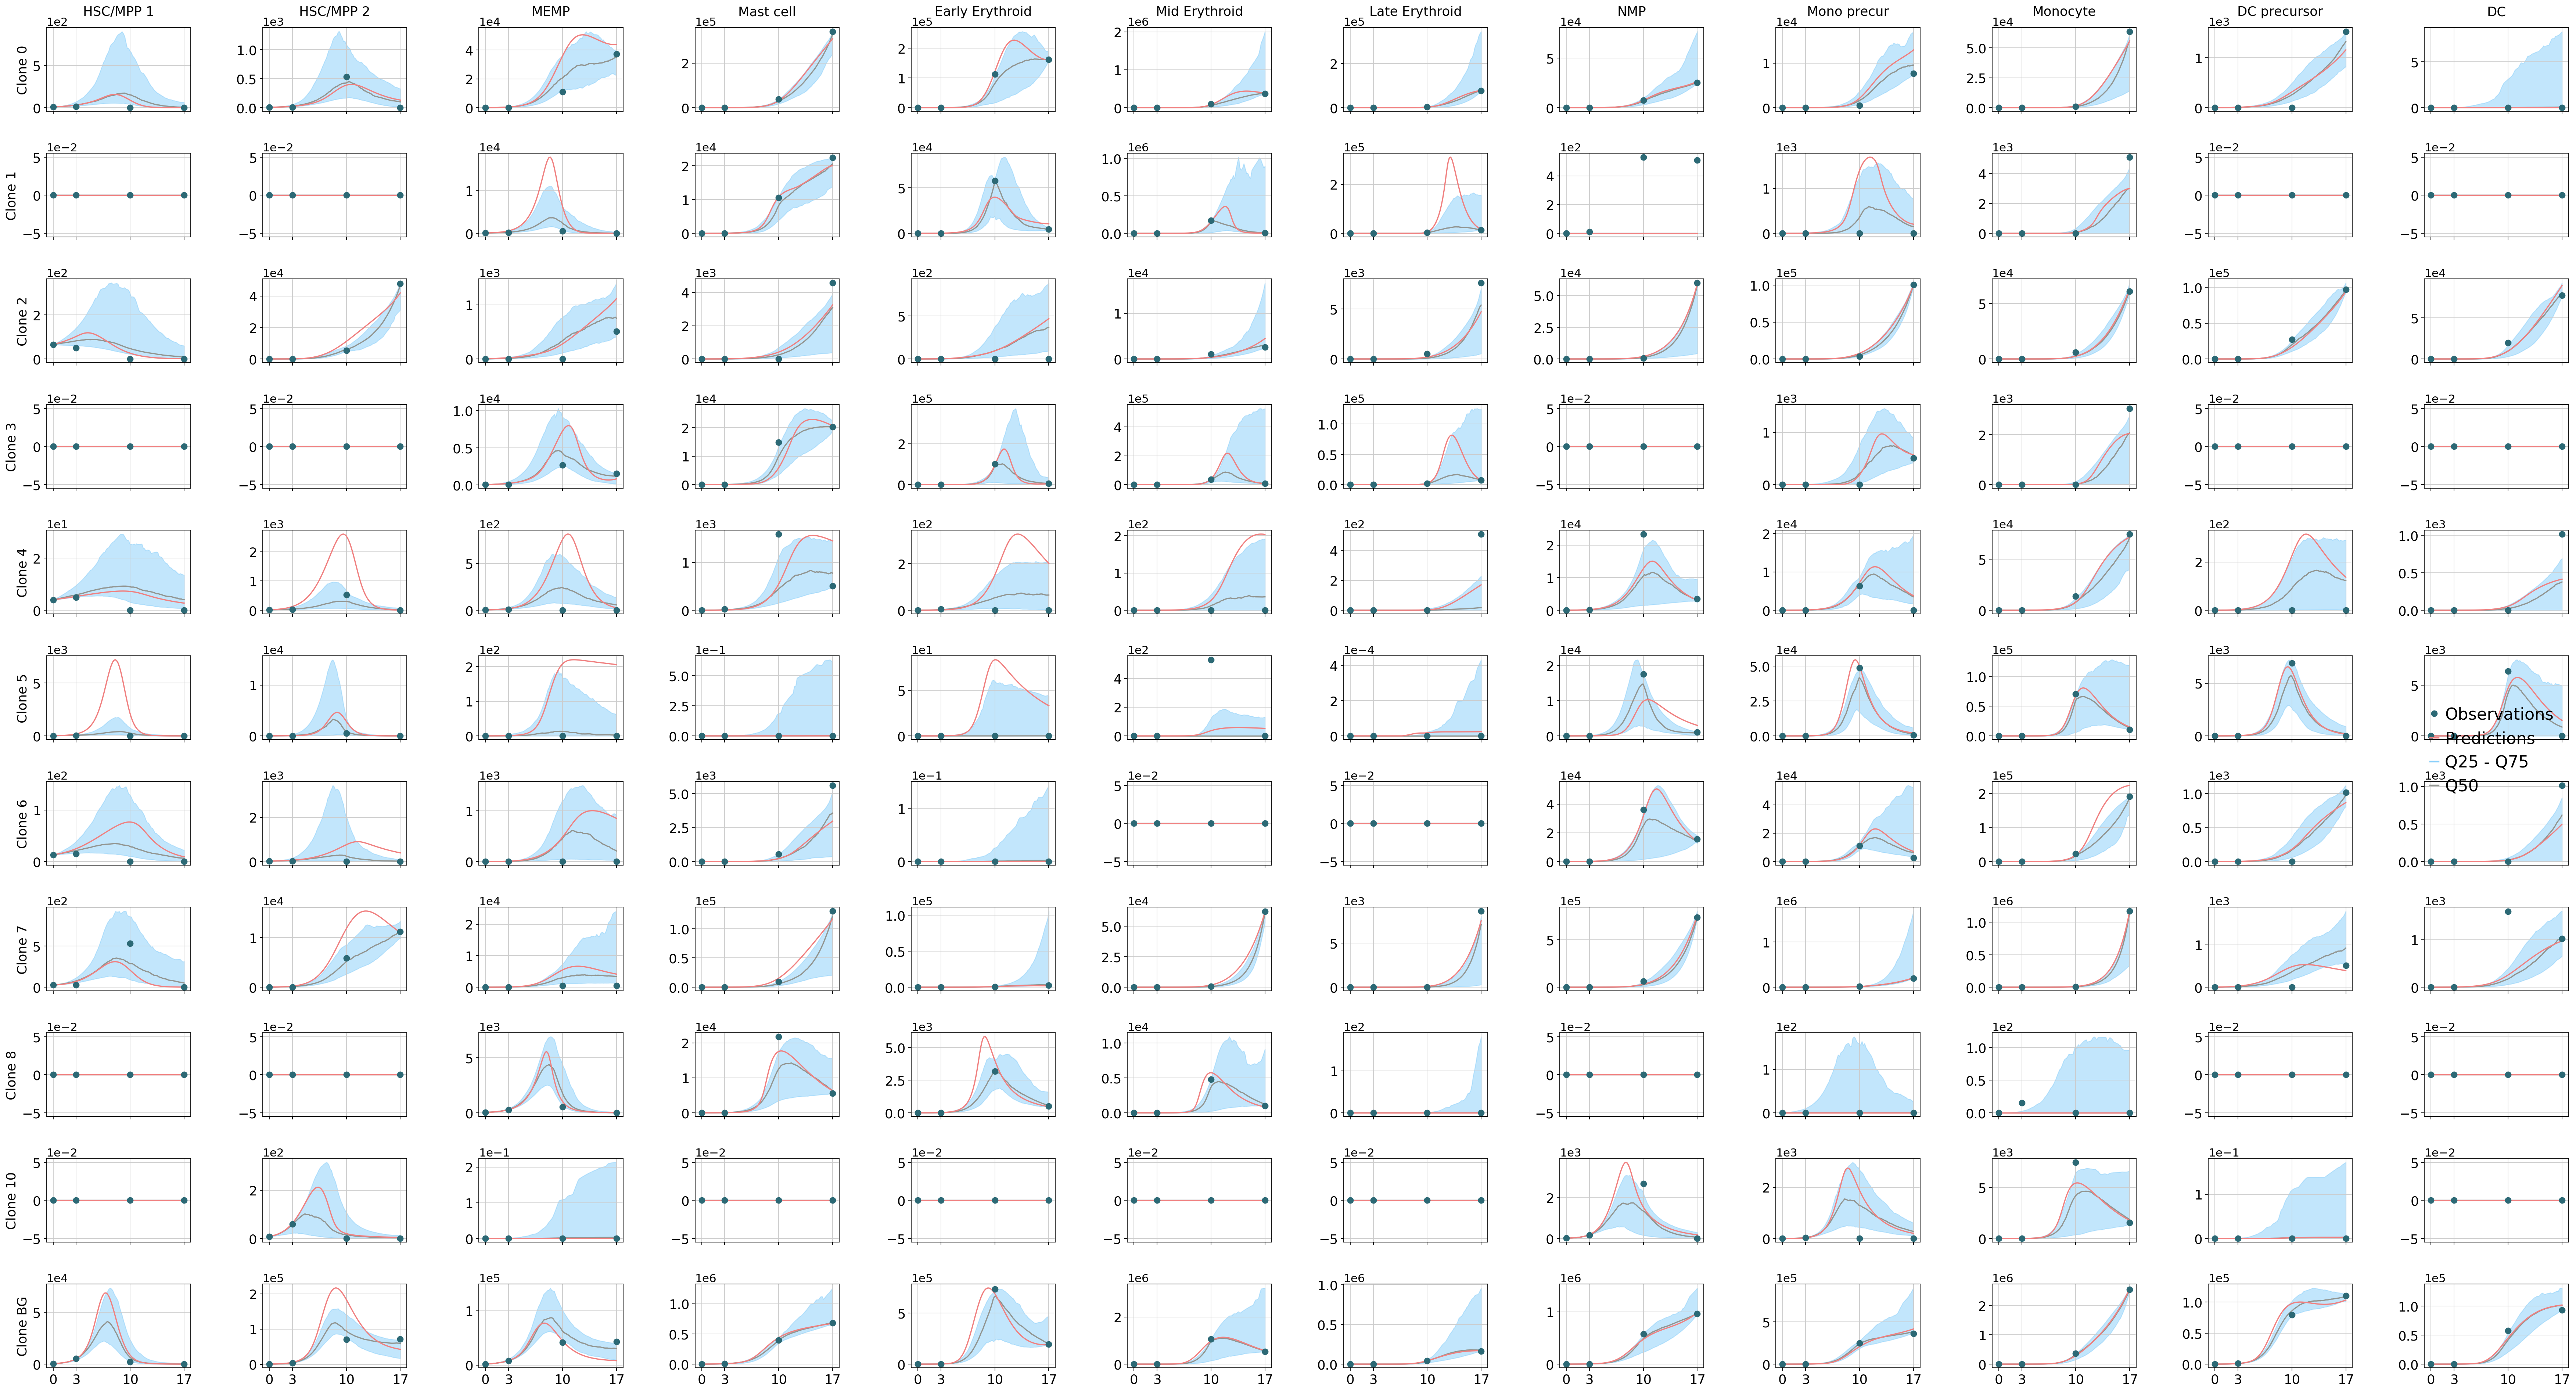

In [24]:
from clonaltrans.pl import trajectory_ci
trajectory_ci(model_list, model, 'cpu', save='cb_trajectory_ci')

### Panel G

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/torchdiffeq/_impl/misc.py:296: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")


---> Negative values were cut to the opposite of positive values for visualization purpose. <---


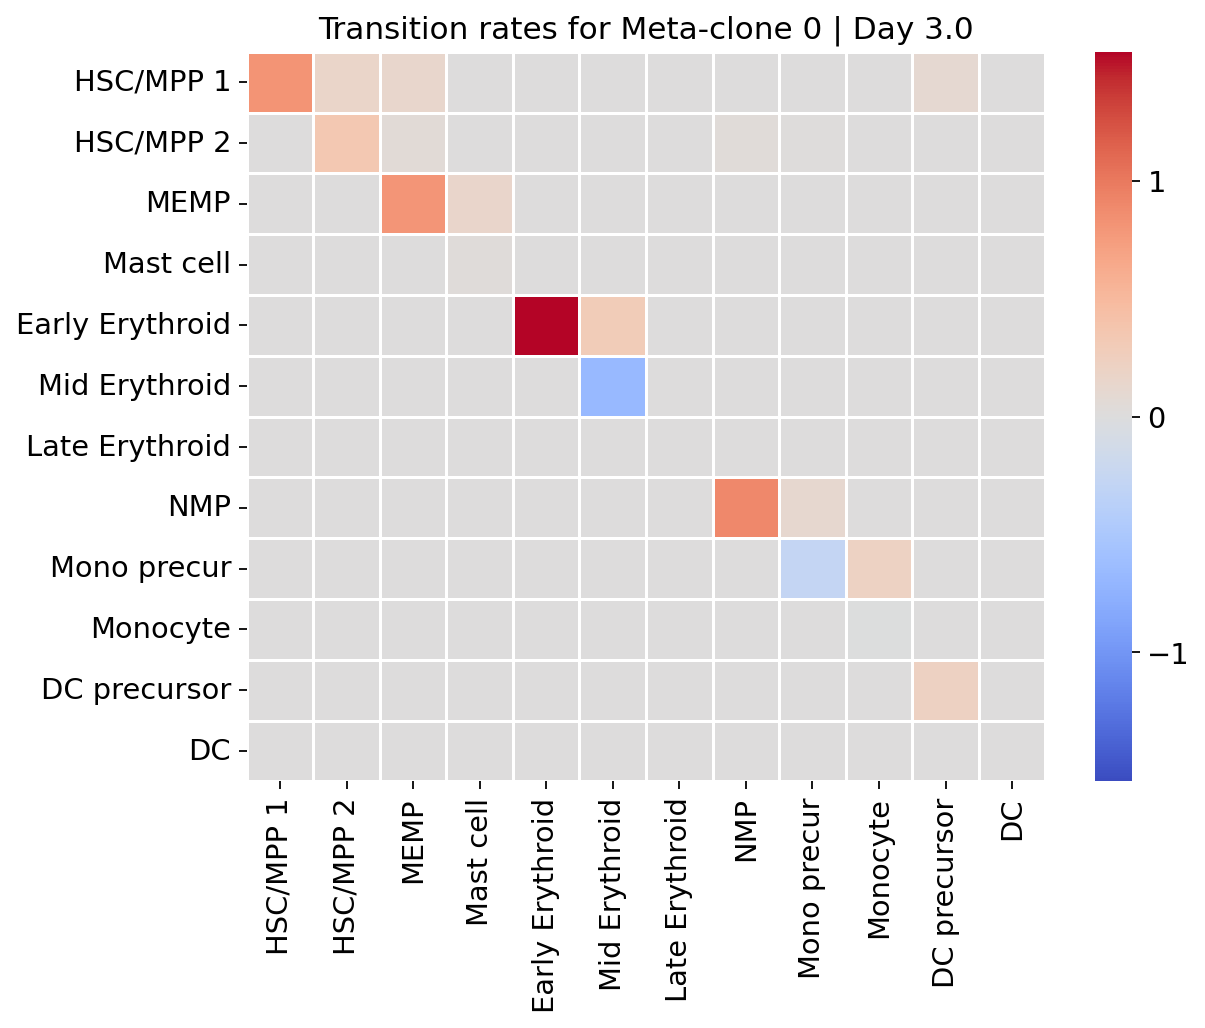

In [25]:
from clonaltrans.pl import clone_specific_K
clone_specific_K(model, index_clone=0, tpoint=3.0, save='cb_clone_specific_K')

### Panel H

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/torchdiffeq/_impl/misc.py:296: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")


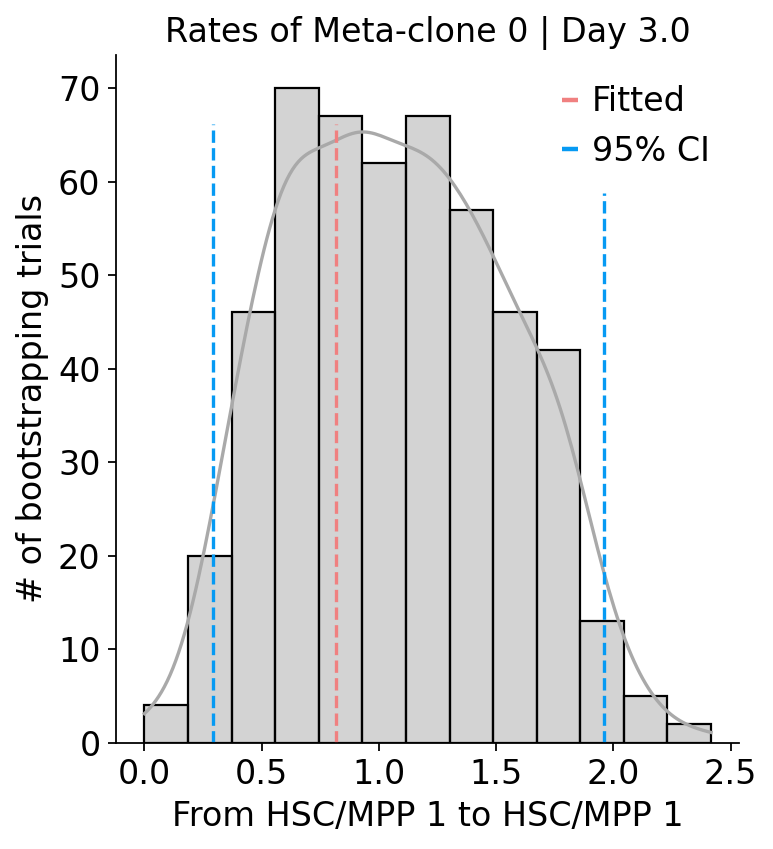

In [26]:
from clonaltrans.pl import parameter_ci
parameter_ci(
    model_list, 
    model, 
    index_clone=0, 
    pop_1=0, 
    pop_2=0, 
    tpoint=3.0,
    save='cb_parameter_ci_0_0'
)

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/torchdiffeq/_impl/misc.py:296: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")


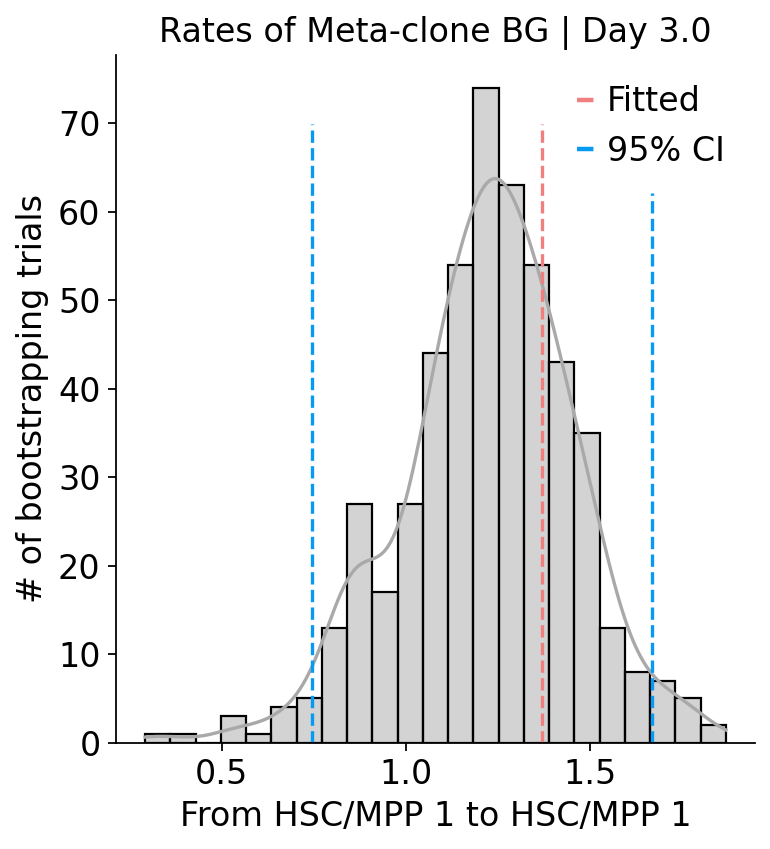

In [27]:
parameter_ci(
    model_list, 
    model, 
    index_clone=-1, 
    pop_1=0, 
    pop_2=0, 
    tpoint=3.0,
    save='cb_parameter_ci_-1_0'
)

### Panel I

In [4]:
from clonaltrans.utils import get_boots_K_total
tpoint = torch.tensor([3.0]).to('cpu')
K_type = model.config['arch']['args']['K_type']
total_K, ref_K = get_boots_K_total(model_list, model, K_type, tpoint)

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/torchdiffeq/_impl/misc.py:296: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")


In [5]:
from clonaltrans.utils import clone_rates_diff_test
p_values, adjusted_p_values, fold_correct = clone_rates_diff_test(model, total_K, correct_method='fdr_bh')
print (p_values.shape, adjusted_p_values.shape, fold_correct.shape)

(55, 12, 12) (27, 55) (27, 55)


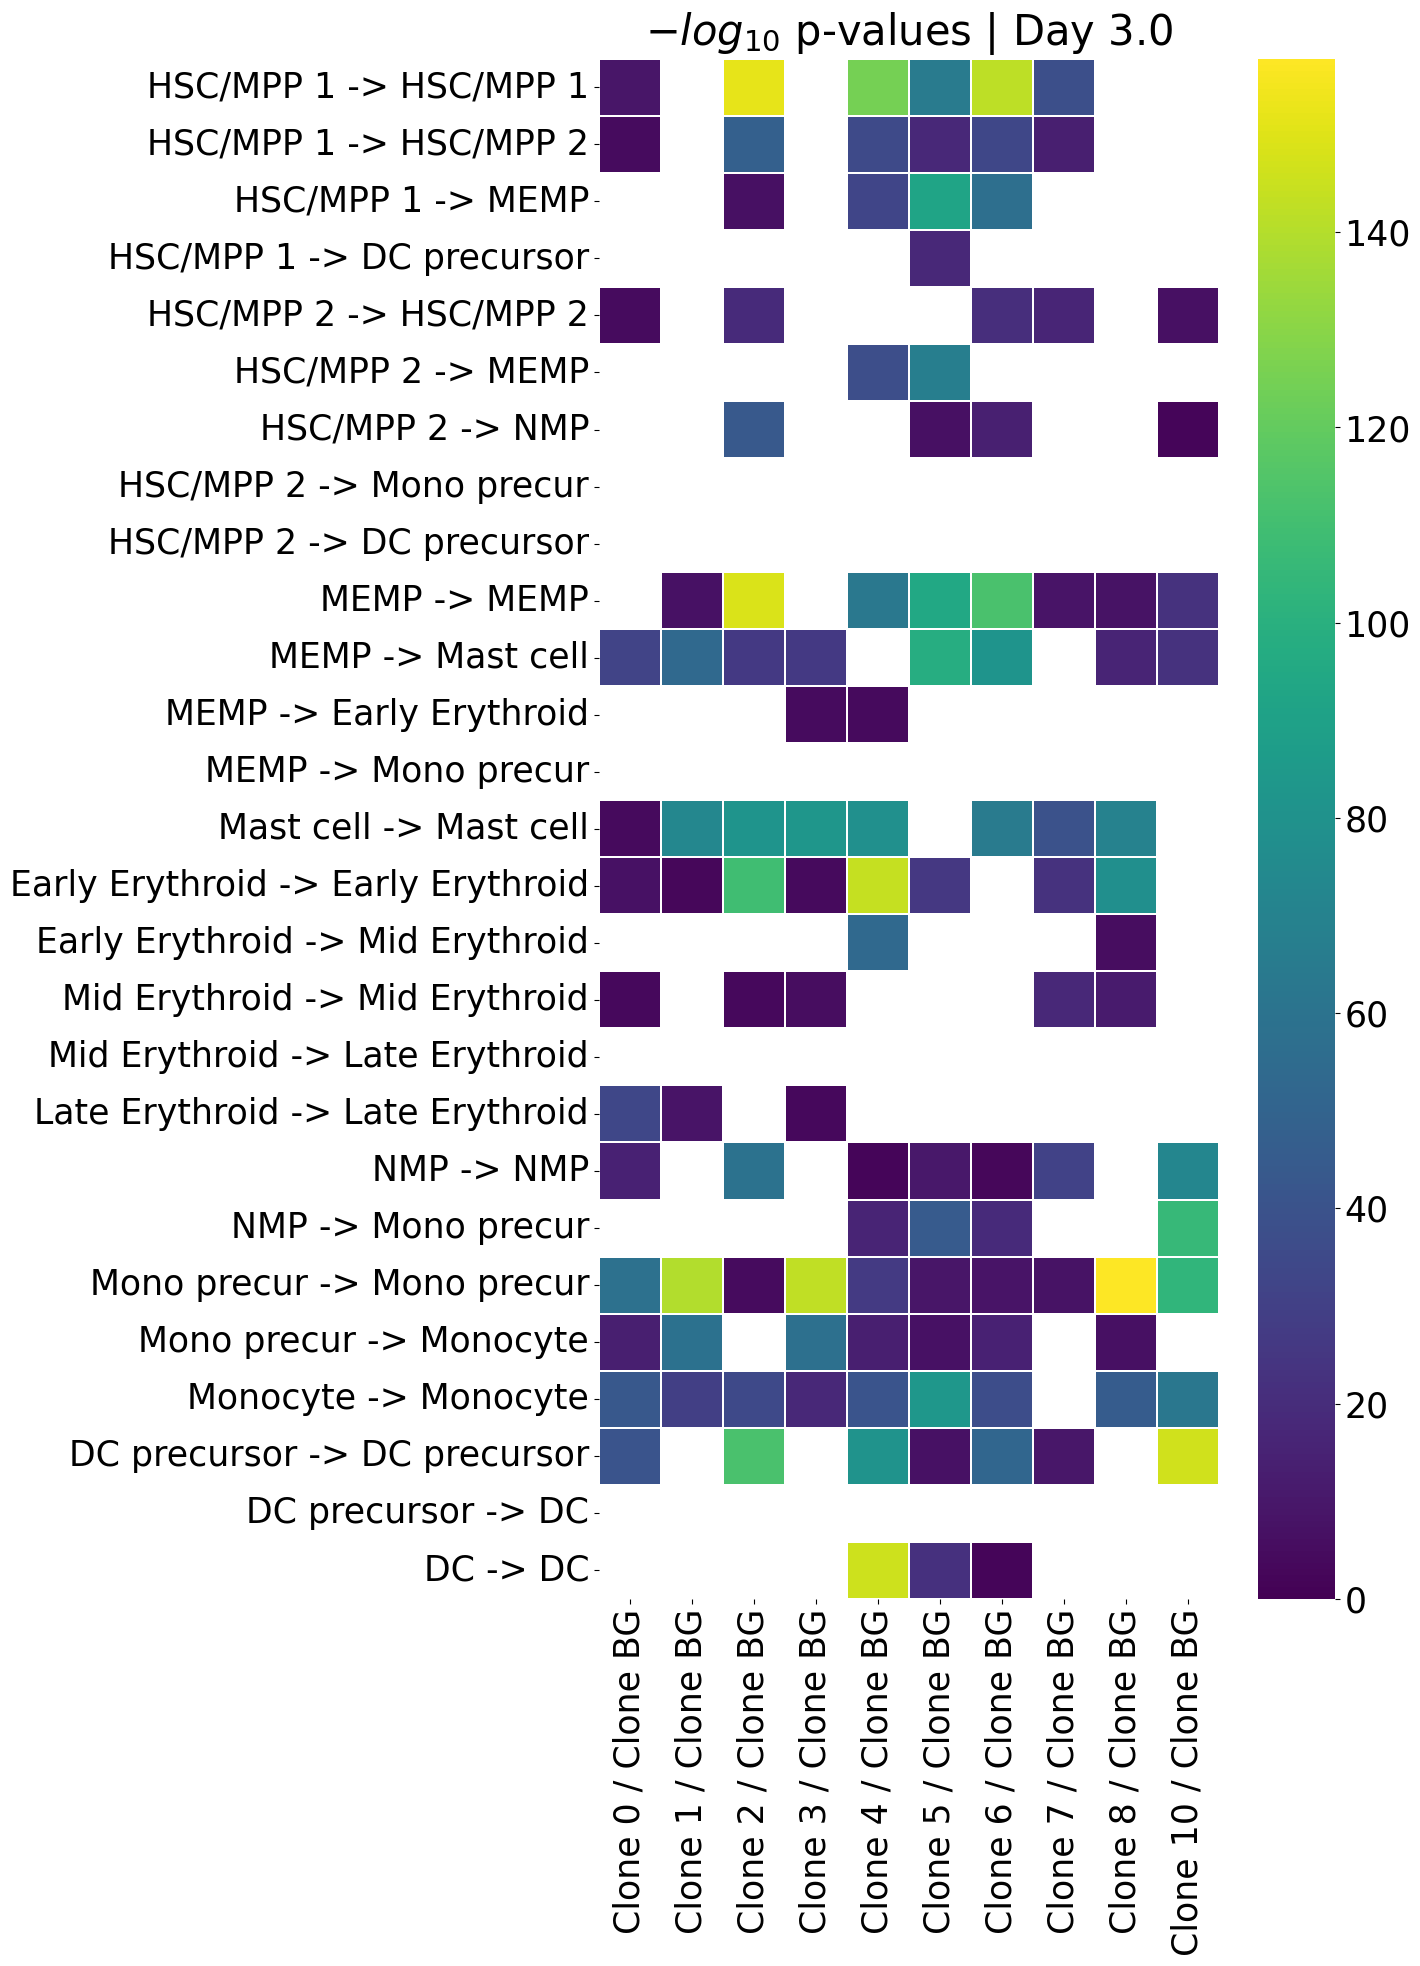

In [8]:
from clonaltrans.pl import clone_rates_diff_plot
clone_rates_diff_plot([adjusted_p_values, fold_correct], model, 'combined', save='cb_clone_rates_diff')